In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
from walkforward_parameter_search import compute_grid_size
from synthetic_returns import estimate_marginal_stats, synthesize_returns
from cscv_pbo_v3 import build_topk_report, cscv_pbo, plot_cscv, plot_topk, calc_dsr_from_matrix,plot_dsr
set_config(transform_output="pandas")
init_logger("CSCV_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\CSCV_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
log_print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


```python
    print(out["report"])                    # 四种分析报告（文本）
    out["pbo"]; out["loss_prob"]; out["degradation"]["slope"]
    out["dominance"]["fsd_holds"]; out["matrix"]; out["meta"]
    plot_cscv(out)                          # 四种分析图（各一张独立画布）
    print(build_topk_report(out, k=5))      # topK 冠军候选验收（文本,零重算）
    plot_topk(out, k=5)                     # topK 评估区累计净值（黑虚线=全员截面中位）
    out_mdd = cscv_pbo(X, space=search_space, block_size=252, S=16,
                       measure="MAX_DRAWDOWN")  # 切换评价度量（skfolio 口径）
'nondomin__fitness_measures': [
    # 长度 2：冠军的核心对
    "mean-variance",                   # 已有
    "mean-avgdd",                      # 新增
    "mean-kurt",                       # 新增
    # 长度 3：冠军删一格
    "mean-variance-avgdd",             # 已有
    "mean-variance-kurt",              # 已有
    "mean-avgdd-kurt",                 # 新增
    # 长度 4：冠军换一格
    "mean-variance-avgdd-kurt",        # 已有（基准）
    "mean-semivariance-avgdd-kurt",    # 新增（波动格→半方差）
    "mean-semideviation-avgdd-kurt",   # 新增（波动格→半标准差）
    "mean-mad-avgdd-kurt",             # 已有（波动格→MAD）
    "mean-variance-maxdd-kurt",        # 已有（回撤格→最大回撤）
    "mean-variance-cvar-kurt",         # 新增（回撤格→CVaR）
    "mean-variance-avgdd-cvar",        # 新增（形状格→CVaR）
    "mean-variance-avgdd-sharpe",      # 新增（形状格→夏普）
    # 长度 5：冠军加一格
    "mean-variance-maxdd-avgdd-kurt",  # 新增（加最大回撤）
    "mean-variance-avgdd-cvar-kurt",   # 新增（加 CVaR）
    "mean-variance-avgdd-kurt-sharpe", # 新增（加夏普）
    "mean-variance-mad-avgdd-kurt",    # 新增（加 MAD）
    ],
```

In [3]:
search_space = {'nondomin__min_n_assets': {'low': 25, 'high': 55, 'step': 10},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.9, 'step': 0.4},
 'extremes__k': {'low': 0.1, 'high': 0.9, 'step': 0.4},
 'nondomin__fitness_measures': [
    "sharpe-cvar",
    "sortino-semivariance",
    "calmar-variance",
    "mean-variance-avgdd",
    "mean-semivariance-maxdd",
    "mean-semideviation-kurt",
    "mean-mad-semideviation-calmar",
    "mean-variance-mad-sortino",
    "mean-kurt-calmar-sharpe",
    "mean-mad-maxdd-avgdd-cvar",
    "mean-semivariance-avgdd-kurt-sharpe",
    "mean-semideviation-maxdd-cvar-sortino",
    ],
 'train_size': {'low': 252, 'high': 504, 'step': 252}}  # inner train size
log_print(search_space, section='Search Space', echo=False)
compute_grid_size(search_space)

2592

In [4]:
out = cscv_pbo(X, space=search_space, block_size=252, S=16)

空间枚举（v3）：6 维 -> N = 2592 个配置（确定性网格，无搜索层）
  收益流构建（v3）：2592 参数 x 8 块 x 252 天 = 2016 天 | 公共起点第 504 天（冗余 504 天）
  对齐网格：train_size 分 2 组，walkforward 每组定义一次、组内复用 | 折级并行 n_jobs = 8（上限即折数 8；省内存可显式传小）


收益流构建:   0%|          | 0/2592 [00:00<?, ?候选/s]

KeyboardInterrupt: 

In [35]:
log_print( out["report"], section="CSCV PBO 诊断", echo=True)

   CSCV PBO 诊断 v3（空间枚举 N 次执行 + 四种分析，论文 3.1-3.3）
  候选集：参数空间网格 N = 3600（6 维，无搜索层）
    - nondomin__min_n_assets: 15~105 step 10
    - nondomin__threshold: -0.5~-0.3 step 0.1
    - correlate__threshold: 0.1~0.7 step 0.3
    - extremes__k: 0.1~0.9 step 0.2
    - nondomin__fitness_measures: choice x4
    - train_size: 252~504 step 252
  收益流：3600 参数 x 8 块 x 252 天 = 2016 天 | 公共起点第 504 天（冗余 max(train_size) = 504 天）
  评估区：2018-01-25 00:00:00+08:00 ~ 2026-05-25 00:00:00+08:00
  CSCV：S=16 块（每块 126 天）| 组合数 C(16,8) = 12870
  ---------- 四种分析 ----------
  [1] PBO = freq(lambda<=0) = 23.4%（3010/12870）| lambda 5/50/95 分位 = -2.09/+1.42/+4.04 | 冠军多样性 187/3600
  [2] 性能退化：SR_OOS = +0.136 -0.786 x SR_IS（Spearman -0.565）| 可达 OOS 区间 P10/50/90 = +0.02/+0.06/+0.08
  [3] 亏损概率：Prob[SR_OOS(IS 冠军) < 0] = 2.0%
  [4] 随机占优：FSD = 否（CDF 最大反超 +0.0000）| SD2 min = +0.0000 -> 仅二阶占优（风险厌恶下优于随机选择）
  解读：PBO 越接近 0 排名传递性越好（论文惯例阈值 5%）；≈50% 表示选择与随机无异；
        亏损概率与 PBO 独立——PBO 低而亏损概率高说明 OOS 乏力且非过拟合所致；
        斜率显著为负 + FSD/SD2 均不成立 =

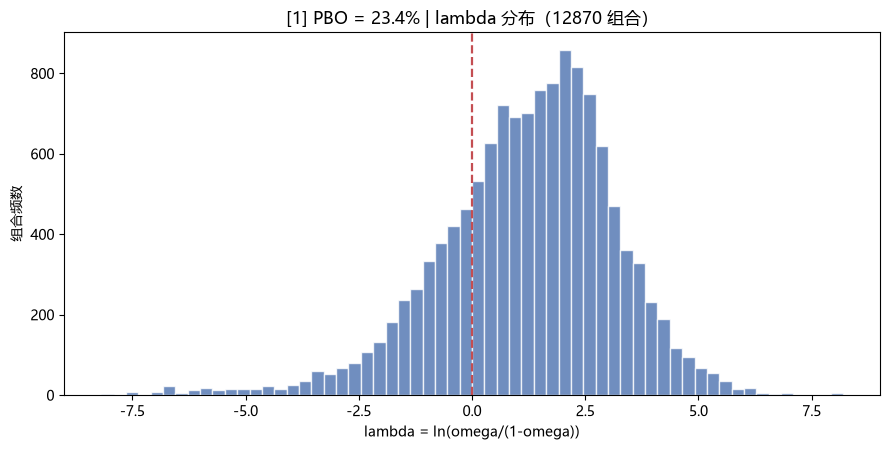

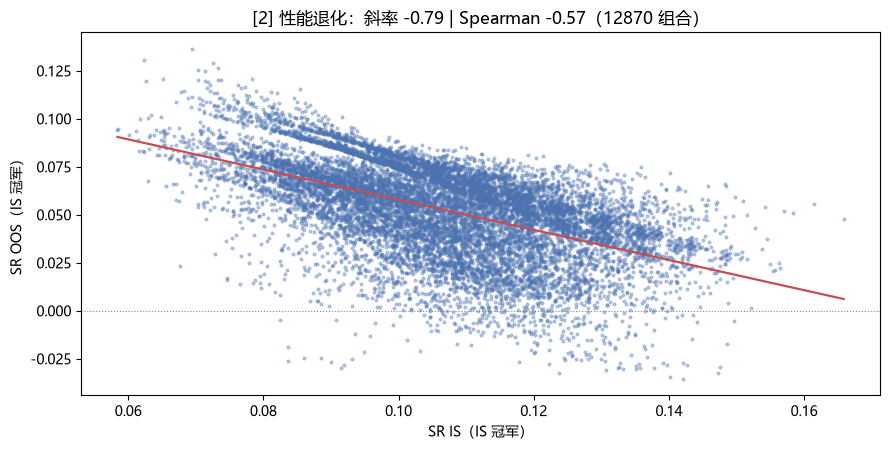

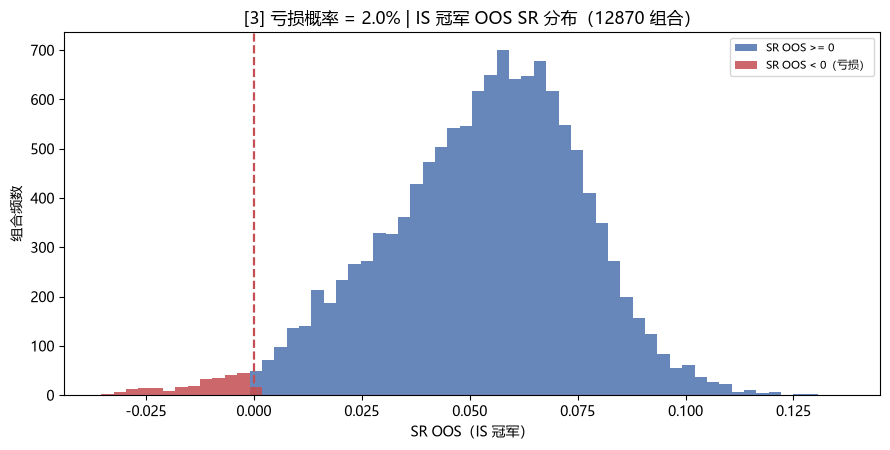

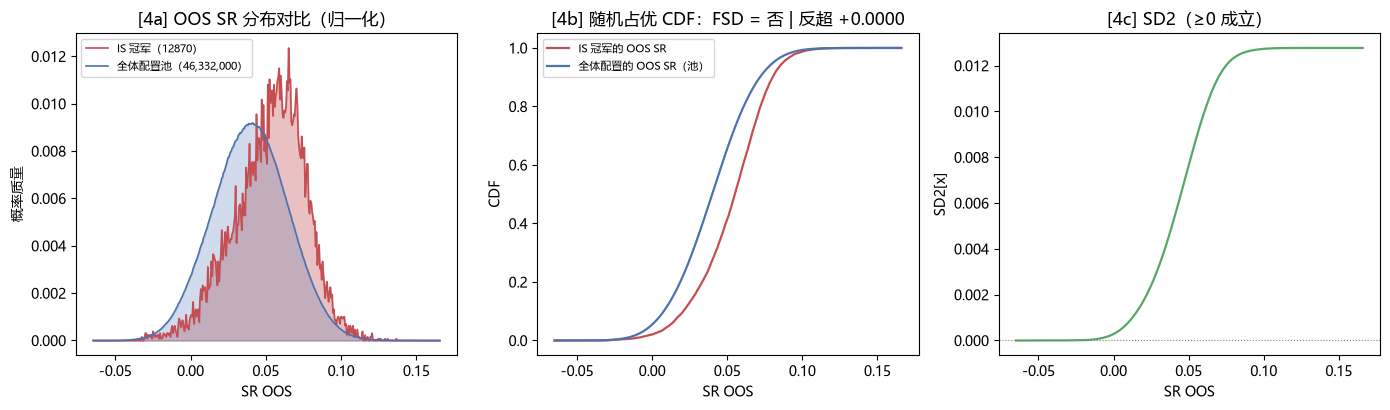

{'pbo': <Figure size 900x460 with 1 Axes>,
 'degradation': <Figure size 900x460 with 1 Axes>,
 'loss': <Figure size 900x460 with 1 Axes>,
 'dominance': <Figure size 1400x420 with 3 Axes>}

In [36]:
plot_cscv(out)                                          # lambda 分布图

In [37]:
log_print(build_topk_report(out, k=10),section="topK 冠军候选样本外验收报告",echo=True)      # topK 冠军候选验收（文本,零重算）

[数据来源] 零重算 | 候选 N=3600 x 评估区 T=2016 天 | 对称组合 12870 个 | S=16
[top10 定位(夺冠次数 | 参数)]
  2154  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 504}
  1315  {'nondomin__min_n_assets': 85, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-variance', 'train_size': 252}
  837  {'nondomin__min_n_assets': 85, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-variance', 'train_size': 252}
  730  {'nondomin__min_n_assets': 95, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.7, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 252}
  469  {'nondomin__min_n_assets': 15, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance', 'tr

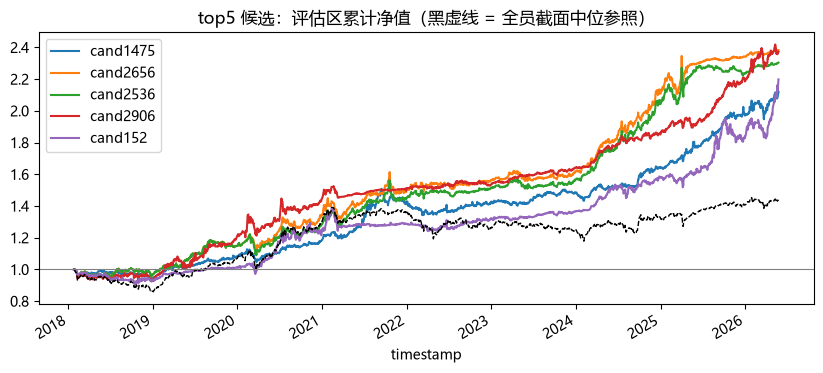

In [39]:
plot_topk(out, k=5)                     # topK 评估区累计净值（黑虚线=全员截面中位）

In [19]:
print(build_topk_report(out, k=20))

[数据来源] 零重算 | 候选 N=2916 x 评估区 T=2016 天 | 对称组合 12870 个 | S=16
[top20 定位(夺冠次数 | 参数)]
  4168  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 504}
  1444  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.6, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 252}
  808  {'nondomin__min_n_assets': 45, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.1, 'extremes__k': 0.6, 'nondomin__fitness_measures': 'mean-mad-avgdd-cvar-sharpe', 'train_size': 252}
  658  {'nondomin__min_n_assets': 35, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-mad-avgdd-cvar-sharpe', 'train_size': 252}
  563  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.7, 'nondomin__fitness_measu

In [40]:
info = calc_dsr_from_matrix(out["matrix"])

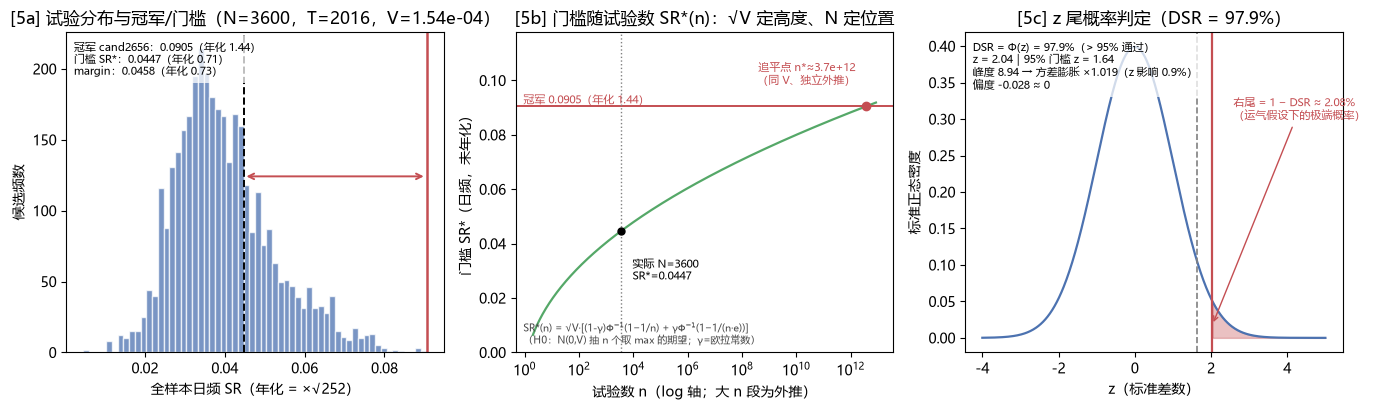

In [41]:
plot_dsr(out, dsr=info)   # info 就是你已有那格算好的 dict；不传也行，内部会重算

In [42]:
log_print(info, section='DSR',echo=True)

{'dsr': 0.9791865572350668, 'z_score': 2.037231131253702, 'sr_obs': 0.0905251382614179, 'sr_star': 0.04471701945082103, 'margin': 0.045808118810596876, 'V': 0.00015402138628158683, 'N': 3600, 'T': 2016, 'skew': -0.02768666657301102, 'kurt': 8.942200735286033, 'champion': 2656}
